# DCA в индекс Nikkei 225 (в долларах) — две подзадачи

**Условие.** Инвестор с 01.01.1990 каждую неделю (понедельник, на открытии рынка) покупает индекс на одинаковую сумму в долларах.

1. **Задача 1.** Какую долларовую доходность он получит на последний день истории?
2. **Задача 2.** Реализовать метод, который увеличивает доходность и уменьшает время нахождения в просадке.



# Задача 1

Покупаем индекс на `$100` в первый торговый день каждой недели.

In [ ]:
!pip install arch -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from arch import arch_model

FX_PATH    = "/content/jpyusd-1.csv"
INDEX_PATH = "/content/nikkei_225-1.csv"
START_DATE = "1990-01-01"
WEEKLY_USD = 100.0     # одинаковая сумма в долларах каждую неделю

## Загрузка данных

In [ ]:
def _to_number(s):
    """Убирает разделители тысяч ('38,915.87') и пропуски FRED ('.'), приводит к float."""
    return pd.to_numeric(s.astype(str).str.replace(",", "", regex=False).str.strip(),
                         errors="coerce")

def load_data(fx_path, index_path):
    fx = pd.read_csv(fx_path, sep=None, engine="python")
    fx.columns = [c.strip() for c in fx.columns]
    fx["DATE"] = pd.to_datetime(fx["DATE"])
    fx["DEXJPUS"] = _to_number(fx["DEXJPUS"])
    fx = fx.dropna(subset=["DEXJPUS"]).sort_values("DATE")

    idx = pd.read_csv(index_path, skiprows=1, sep=None, engine="python")
    idx.columns = [c.strip() for c in idx.columns]
    date_col  = next(c for c in idx.columns if c.lower().startswith("date"))
    price_col = next(c for c in idx.columns
                     if c.lower().startswith("price") or c.lower().startswith("close"))
    idx["Date"]  = pd.to_datetime(idx[date_col])
    idx["Price"] = _to_number(idx[price_col])
    idx = idx.dropna(subset=["Price"]).sort_values("Date")

    # последний доступный курс на/до каждого торгового дня индекса
    df = pd.merge_asof(idx[["Date", "Price"]],
                       fx[["DATE", "DEXJPUS"]].rename(columns={"DATE": "Date"}),
                       on="Date", direction="backward")
    df["Price_USD"] = df["Price"] / df["DEXJPUS"]   # Nikkei (иены) / (иен за доллар) -> доллары
    return df.dropna(subset=["Price_USD"]).reset_index(drop=True)

def mark_buy_days(df):
    """Первый торговый день каждой ISO-недели = день покупки (понедельник или следующий торговый день)."""
    df = df.copy()
    iso = df["Date"].dt.isocalendar()
    df["week_id"] = iso["year"].astype(int) * 100 + iso["week"].astype(int)
    df["BuyDay"]  = ~df["week_id"].duplicated()
    return df

## Стратегия

In [ ]:
def base(df, weekly_usd=WEEKLY_USD):
    """фиксированная сумма в первый торговый день каждой недели"""
    df = df.copy()
    df["contribution"] = np.where(df["BuyDay"], weekly_usd, 0.0)
    df["units"] = (df["contribution"] / df["Price_USD"]).cumsum()
    df["value"] = df["units"] * df["Price_USD"]
    return df[["Date", "Price_USD", "contribution", "value"]]

## Результат

In [ ]:
# Загрузка и фильтрация с 1990 года
full = load_data(FX_PATH, INDEX_PATH)
inv = mark_buy_days(full[full["Date"] >= START_DATE].copy())

base_results = base(inv)

# Вывод результатов
total_invested = base_results["contribution"].sum()
final_value = base_results["value"].iloc[-1]
profit_usd = final_value - total_invested

print(f"Результаты с {START_DATE}:")
print(f"Всего вложено:         ${total_invested:,.0f}")
print(f"Стоимость на конец:    ${final_value:,.0f}")
print(f"ИТОГОВАЯ ПРИБЫЛЬ ($):  ${profit_usd:,.0f}")
print(f"Общая доходность:      {(final_value / total_invested - 1) * 100:.2f}%")

Результаты с 1990-01-01:
Всего вложено:         $183,700
Стоимость на конец:    $325,485
ИТОГОВАЯ ПРИБЫЛЬ ($):  $141,785
Общая доходность:      77.18%


# Задача 2



Стратегия использует скользящую среднюю за 200 дней (SMA200) как индикатор направления тренда: если цена выше неё — тренд восходящий, ниже — нисходящий. Каждую неделю инвестор не продаёт уже купленное, а лишь решает судьбу новых $100: при восходящем тренде он на них покупает индекс, а при нисходящем — откладывает деньги в кэш-копилку, не заводя их в падающий рынок. Пока тренд внизу, взносы копятся в кэше; как только цена пробивает SMA200 снизу вверх (разворот), весь накопленный буфер разом вкладывается в индекс

In [ ]:
SMA_WINDOW = 200
inv["SMA"] = inv["Price_USD"].rolling(SMA_WINDOW).mean()

def backtest_trend_buffer(df, weekly_usd=WEEKLY_USD):
    df = df.copy().reset_index(drop=True)
    units = cash = 0.0; prev = None; contrib = []; val = []
    for price, sma, buy in zip(df["Price_USD"], df["SMA"], df["BuyDay"]):
        c = weekly_usd if buy else 0.0
        above = True if pd.isna(sma) else price > sma
        if prev is False and above and cash > 0:
            units += cash / price; cash = 0.0
        if buy:
            if above:
                units += c / price
            else:
                cash  += c                     # тренд вниз -> откладываем (без продаж)
        prev = above;
        contrib.append(c);
        val.append(units * price + cash)
    df["contribution"] = contrib;
    df["value"] = val
    return df[["Date", "Price_USD", "contribution", "value"]]


In [ ]:
def metrics(bt):
    inv_t = bt["contribution"].sum(); fin = bt["value"].iloc[-1]
    v = bt["value"].to_numpy(float); peak = np.maximum.accumulate(v); dd = v/peak - 1
    return {"Итог, $": round(fin), "Прибыль, $": round(fin - inv_t),
            "Доходность, %": round((fin/inv_t - 1)*100, 1),
            "Макс. просадка, %": round(dd.min()*100, 1),
            "Время в просадке, %": round((v < peak).mean()*100, 1)}

In [ ]:
tb = backtest_trend_buffer(inv)
print("\n"+"="*64, "\nШаг 3. Сравнение стратегий")
print(pd.DataFrame({"Base": metrics(base_results),
                    "Advanced": metrics(tb)}).T.to_string())


Шаг 3. Сравнение стратегий
           Итог, $  Прибыль, $  Доходность, %  Макс. просадка, %  Время в просадке, %
Base      325485.0    141785.0           77.2              -55.0                 92.6
Advanced  326816.0    143116.0           77.9              -49.9                 92.5


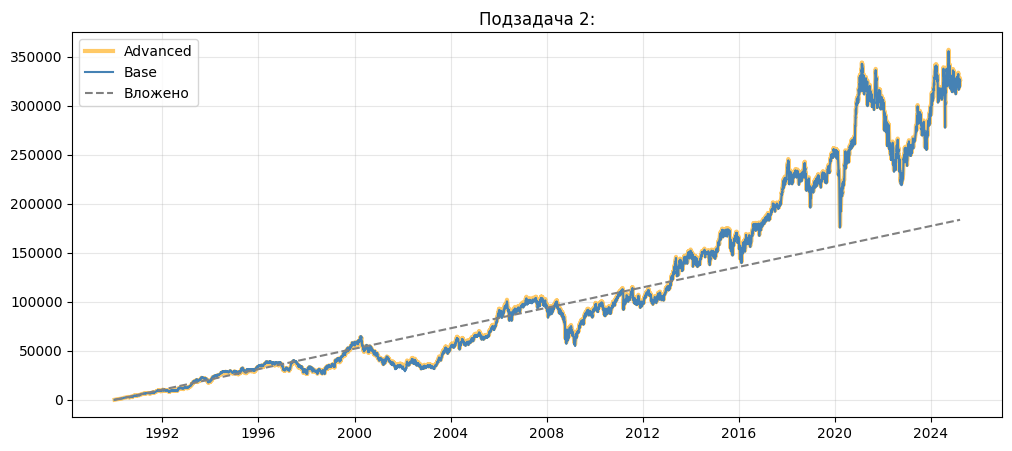

In [ ]:
# ---- График ----
plt.figure(figsize=(12, 5))
plt.plot(tb["Date"], tb["value"], color="orange", lw=3, alpha=.6,
         label="Advanced")
plt.plot(base_results["Date"], base_results["value"], color="steelblue", lw=1.5,
         label="Base")                                   # тонкой линией поверх
plt.plot(base_results["Date"], base_results["contribution"].cumsum(),
         "--", color="gray", label="Вложено")
plt.title("Подзадача 2:")
plt.legend(); plt.grid(alpha=.3); plt.show()

## Стратегия с продажей

Стратегия (трендовый фильтр с частичными продажами). В качестве индикатора направления используется короткая скользящая средняя SMA(12): пока цена выше неё, рынок считается растущим, ниже — падающим. Когда цена опускается ниже SMA, стратегия уводит в кэш долю exit_frac (70%) всего портфеля, но оставшуюся часть держит в индексе — то есть снижает риск частично, не выходя полностью; при возврате цены выше SMA весь накопленный кэш снова инвестируется. Еженедельные взносы по $100 при этом идут в индекс в «рисковом» режиме и копятся в кэше в «защитном». Параметр band (3%) добавляет буфер на возврат, чтобы не дёргаться туда-сюда у самой средней, а weekly_signal проверяет правило только в дни покупки — вместе они уменьшают число ложных переключений.

In [ ]:
SMA_WINDOW = 12
inv["SMA"] = inv["Price_USD"].rolling(SMA_WINDOW).mean()

def backtest_overlay(df, exit_frac=0.7, band=0.03, weekly_signal=True, weekly_usd=WEEKLY_USD):
    df = df.copy().reset_index(drop=True)
    units = cash = 0.0;
    risk_on = True;
    contrib = [];
    val = []
    for price, sma, buy in zip(df["Price_USD"], df["SMA"], df["BuyDay"]):
        c = weekly_usd if buy else 0.0
        if not pd.isna(sma) and (buy or not weekly_signal):
            if risk_on and price < sma*(1 - band):
                move = units*exit_frac;
                cash += move*price;
                units -= move;
                risk_on = False
            elif (not risk_on) and price > sma*(1 + band):
                units += cash/price;
                cash = 0.0;
                risk_on = True
        if buy:
            if risk_on:
                units += c/price
            else:
                cash += c
        contrib.append(c);
        val.append(units*price + cash)
    df["contribution"] = contrib;
    df["value"] = val
    return df[["Date", "Price_USD", "contribution", "value"]]


strat = backtest_overlay(inv)
print(pd.DataFrame({"Base": metrics(base_results),
                    "Стратегия (выход 70%)": metrics(strat)}).T.to_string())

                        Итог, $  Прибыль, $  Доходность, %  Макс. просадка, %  Время в просадке, %
Base                   325485.0    141785.0           77.2              -55.0                 92.6
Стратегия (выход 70%)  336894.0    153194.0           83.4              -49.0                 92.4


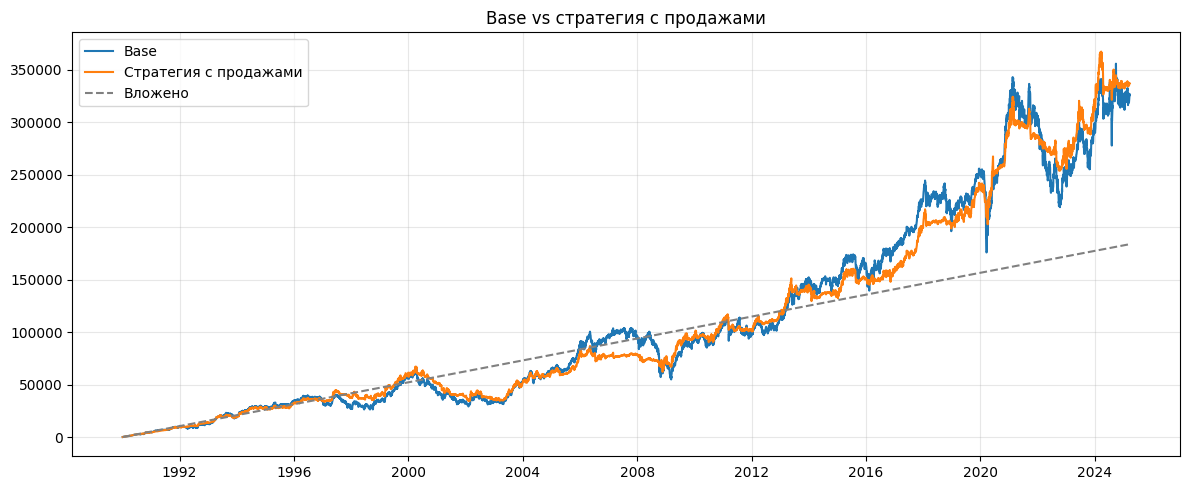

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(base_results["Date"], base_results["value"], label="Base")
plt.plot(strat["Date"], strat["value"], label="Стратегия с продажами")
plt.plot(base_results["Date"], base_results["contribution"].cumsum(), "--", color="gray", label="Вложено")
plt.title("Base vs стратегия с продажами")
plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()